# model 2 — deep neural network prototype
*messy working notebook — figuring out the DNN architecture*

**Sean McManus — ML/DNN Lead**  
goal: build a DNN on the same tabular encounter data as model 1  
then compare AUC against XGBoost — does deep learning actually help here?  
spoiler: probably not by much, tabular data is XGBoost's home turf

## 1. imports

In [21]:
import sys
import os
from pathlib import Path

# suppress tensorflow info/warning logs — just show errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)

# tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print(f'tensorflow: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

# check actual metric key names — these change between TF versions
# we need to know this before plotting
print('imports done')

tensorflow: 2.20.0
GPU available: False
imports done


## 2. load and prep data
reusing the exact same pipeline as model 1 — critical for fair comparison  
if we preprocess differently the AUC comparison means nothing

In [22]:
from pipelines.data_pipeline import load_raw_data, clean_data, engineer_features, split_data

df = load_raw_data('patient_encounters_2023.csv')
print(f'raw shape: {df.shape}')

df = clean_data(df)
df = engineer_features(df)
print(f'processed shape: {df.shape}')

raw shape: (101766, 50)
processed shape: (95637, 113)


In [23]:
TARGET = 'readmission_binary'
DROP_COLS = ['encounter_id', 'patient_nbr', 'Unnamed: 0', 'readmitted']

y = df[TARGET].astype(int)
X = df.drop(columns=[c for c in DROP_COLS + [TARGET] if c in df.columns])

# one-hot encode any leftover object columns
obj_cols = X.select_dtypes(include='object').columns.tolist()
if obj_cols:
    print(f'encoding: {obj_cols}')
    X = pd.get_dummies(X, columns=obj_cols, drop_first=True)

X = X.apply(pd.to_numeric, errors='coerce')

print(f'features: {X.shape[1]}')
print(f'class balance: {y.value_counts().to_dict()}')
feature_names = X.columns.tolist()

features: 112
class balance: {0: 50137, 1: 45500}


In [24]:
# same split as model 1 — random_state=42 ensures identical train/val sets
X_train_df, X_val_df, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'train: {len(X_train_df):,}  |  val: {len(X_val_df):,}')
print(f'train readmission rate: {y_train.mean()*100:.1f}%')
print(f'val readmission rate:   {y_val.mean()*100:.1f}%')

train: 76,509  |  val: 19,128
train readmission rate: 47.6%
val readmission rate:   47.6%


## 3. scale features
this is the big difference from model 1 — DNNs REQUIRE scaled inputs  
XGBoost doesnt care about scale, but neural nets do  
unscaled features cause gradient explosions and broken training  
fit scaler on training data ONLY then transform both

In [25]:
# impute first
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_df)
X_val_imp = imputer.transform(X_val_df)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)

print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'mean (should be ~0): {X_train_scaled.mean():.4f}')
print(f'std  (should be ~1): {X_train_scaled.std():.4f}')

X_train_scaled shape: (76509, 112)
mean (should be ~0): 0.0000
std  (should be ~1): 0.9910


In [26]:
# class weights for imbalance handling
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
class_weight = {0: 1.0, 1: float(neg / pos)}
print(f'class weights: {class_weight}')

class weights: {0: 1.0, 1: 1.1018956043956043}


## 4. build the DNN

In [27]:
n_features = X_train_scaled.shape[1]

def build_dnn(n_features, learning_rate=0.001):
    model = Sequential([
        Input(shape=(n_features,)),
        
        # layer 1 — wide first layer
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        
        # layer 2
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        
        # layer 3
        Dense(64, activation='relu'),
        Dropout(0.2),
        
        # output — sigmoid for binary classification
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
        # naming it 'auc' explicitly so the key is always 'auc' not 'auc_1'
    )
    
    return model

model = build_dnn(n_features)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │        28,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,681 (280.00 KB)

 Trainable params: 70,913 (277.00 KB)

 Non-trainable params: 768 (3.00 KB)

## 5. train

In [28]:
early_stop = EarlyStopping(
    monitor='val_auc',
    patience=10,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=256,
    validation_data=(X_val_scaled, y_val),
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5813 - auc: 0.6130 - loss: 0.7294 - val_accuracy: 0.6240 - val_auc: 0.6717 - val_loss: 0.6460 - learning_rate: 0.0010
Epoch 2/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6128 - auc: 0.6589 - loss: 0.6854 - val_accuracy: 0.6262 - val_auc: 0.6768 - val_loss: 0.6433 - learning_rate: 0.0010
Epoch 3/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6240 - auc: 0.6730 - loss: 0.6766 - val_accuracy: 0.6306 - val_auc: 0.6808 - val_loss: 0.6404 - learning_rate: 0.0010
Epoch 4/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6277 - auc: 0.6786 - loss: 0.6730 - val_accuracy: 0.6323 - val_auc: 0.6829 - val_loss: 0.6404 - learning_rate: 0.0010
Epoch 5/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6325 - auc: 0.6824 - loss: 0.6703 - val_accuracy: 0.6335 - val_auc: 0.6838 - val_loss: 0.6393 - learning_rate: 0.0010
Epoch 6/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6343 - a

In [29]:
# always check what keys are actually available before plotting
# TF metric names can vary between versions
print('available history keys:', list(history.history.keys()))

# find the AUC key automatically — works regardless of TF version
auc_key = [k for k in history.history.keys() if 'auc' in k and 'val' not in k][0]
val_auc_key = [k for k in history.history.keys() if 'auc' in k and 'val' in k][0]
print(f'using AUC keys: {auc_key}, {val_auc_key}')

available history keys: ['accuracy', 'auc', 'loss', 'val_accuracy', 'val_auc', 'val_loss', 'learning_rate']
using AUC keys: auc, val_auc


## 6. training curves
want to see if train and val are tracking together  
train keeps improving but val plateaus = overfitting  
both flat and low = underfitting  
tracking close together = good fit

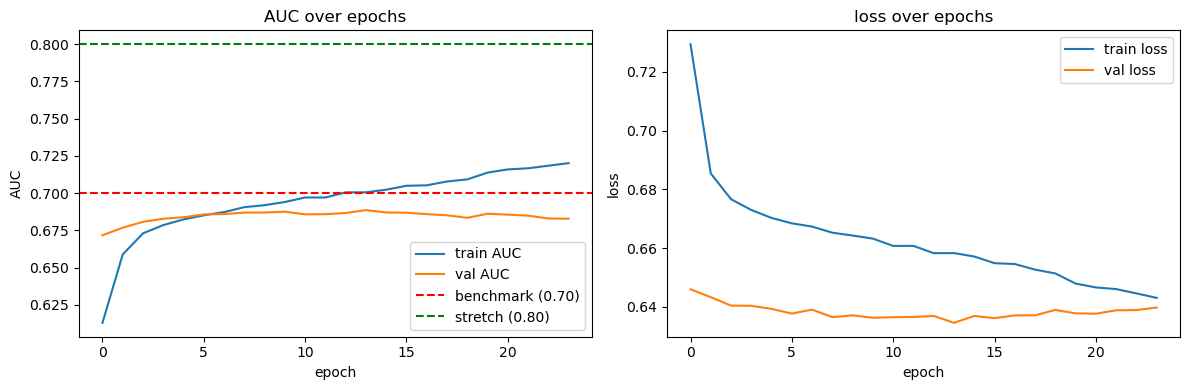

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# AUC curves — using dynamically found keys so this works on any TF version
axes[0].plot(history.history[auc_key], label='train AUC')
axes[0].plot(history.history[val_auc_key], label='val AUC')
axes[0].axhline(y=0.70, color='red', linestyle='--', label='benchmark (0.70)')
axes[0].axhline(y=0.80, color='green', linestyle='--', label='stretch (0.80)')
axes[0].set_title('AUC over epochs')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('AUC')
axes[0].legend()

# loss curves
axes[1].plot(history.history['loss'], label='train loss')
axes[1].plot(history.history['val_loss'], label='val loss')
axes[1].set_title('loss over epochs')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. evaluate and compare to model 1

In [31]:
y_proba = model.predict(X_val_scaled, verbose=0).flatten()
y_pred = (y_proba >= 0.5).astype(int)

dnn_auc = roc_auc_score(y_val, y_proba)

print(f'DNN AUC-ROC: {dnn_auc:.4f}  {"✅" if dnn_auc >= 0.70 else "❌ below 0.70"}')
print(classification_report(y_val, y_pred, target_names=['No Readmit', 'Readmit']))

# comparison against model 1
model1_auc = 0.6865  # update with actual model 1 score
diff = dnn_auc - model1_auc
print(f'Model 1 (XGBoost) AUC: {model1_auc:.4f}')
print(f'Model 2 (DNN) AUC:     {dnn_auc:.4f}')
print(f'Difference:            {diff:+.4f} ({"DNN better" if diff > 0 else "XGBoost better"})')

DNN AUC-ROC: 0.6887  ❌ below 0.70
              precision    recall  f1-score   support

  No Readmit       0.65      0.69      0.67     10028
     Readmit       0.63      0.58      0.61      9100

    accuracy                           0.64     19128
   macro avg       0.64      0.64      0.64     19128
weighted avg       0.64      0.64      0.64     19128

Model 1 (XGBoost) AUC: 0.6865
Model 2 (DNN) AUC:     0.6887
Difference:            +0.0022 (DNN better)


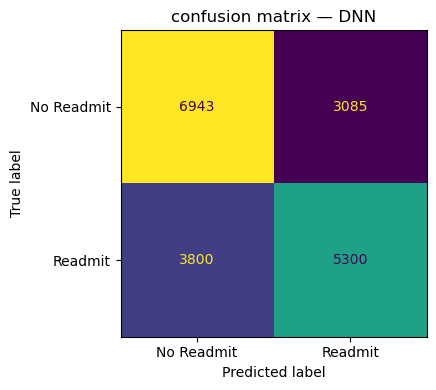

In [32]:
# confusion matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Readmit', 'Readmit'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False)
ax.set_title('confusion matrix — DNN')
plt.tight_layout()
plt.show()

## 8. threshold tuning
default threshold is 0.5 — lowering it catches more readmissions (higher recall)  
but also more false alarms (lower precision)  
clinically, catching a real readmission matters more than avoiding false alarms

In [33]:
for threshold in [0.3, 0.4, 0.5, 0.6]:
    preds = (y_proba >= threshold).astype(int)
    p = precision_score(y_val, preds, zero_division=0)
    r = recall_score(y_val, preds)
    f1 = f1_score(y_val, preds)
    print(f'threshold={threshold:.1f}  precision={p:.3f}  recall={r:.3f}  f1={f1:.3f}')

threshold=0.3  precision=0.514  recall=0.935  f1=0.664
threshold=0.4  precision=0.562  recall=0.794  f1=0.658
threshold=0.5  precision=0.632  recall=0.582  f1=0.606
threshold=0.6  precision=0.697  recall=0.362  f1=0.477


## 9. notes / next steps
- TODO: update that model1_auc variable up there with the actual score
- TODO: get the good architecture into train.py when im happy with it
- TODO: make sure scaler and imputer are saving properly — predict.py needs them
- TODO: figure out what to say about DNN vs XGBoost for the presentation
- NOTE: if the AUC is basically the same as XGBoost thats totally fine  
  tree models just do better on tabular data, thats not a bug thats a feature lol  
  the story is about why we tried it and what the trade-offs are, not about winning